# Peak-Aware vs Baseline — Single-Container Comparison

Manual Day-1 comparison notebook for the Peak-Aware Hybrid research track.

Mirrors the **Primary Evaluation** demo in `hybrid_model.ipynb`, but runs **both** models on one container:

- **Baseline (control):** frozen `baseline_reference` Hybrid Prophet + GRU
- **Peak-aware (treatment):** timestep-weighted training variant

**Change `SAMPLE_CID` in the configuration cell** to inspect any evaluable container.

Outputs:
1. Separate Day-1 forecast plots for baseline and peak-aware
2. Combined overlay (Actual vs Baseline vs Peak-aware)
3. Metric tables (overall + peak / non-peak subsets)


In [1]:
import importlib
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(".."))

import utils.hybrid_config as hybrid_config
import utils.hybrid_artifacts as hybrid_artifacts
import utils.hybrid_evaluation as hybrid_evaluation
import utils.hybrid_inference as hybrid_inference
import utils.peak_evaluation as peak_evaluation

importlib.reload(hybrid_config)
importlib.reload(hybrid_artifacts)
importlib.reload(hybrid_evaluation)
importlib.reload(hybrid_inference)
importlib.reload(peak_evaluation)

from utils.hybrid_config import DAY1_HORIZON, DEFAULT_INPUT_WINDOW
from utils.hybrid_artifacts import load_hybrid_artifacts
from utils.hybrid_evaluation import compute_day1_mape, compute_day1_metrics
from utils.hybrid_inference import run_hybrid_inference
from utils.peak_detection import load_peak_thresholds
from utils.peak_evaluation import compute_peak_subset_metrics_from_arrays
from utils.peak_config import (
    BASELINE_REFERENCE_DIR,
    PEAK_AWARE_MODEL_FILENAME,
    RESIDUAL_STATS_FILENAME,
)

# --- Change this container ID to compare another workload ---
SAMPLE_CID = "c_11461"
TARGET_CID = SAMPLE_CID

# --- Experiment paths (read-only) ---
EXPERIMENT_DIR = Path("../experiments/peak_aware_2026-07-14_164518")
BASELINE_MODEL_DIR = BASELINE_REFERENCE_DIR / "models"
PEAK_AWARE_MODEL_DIR = EXPERIMENT_DIR / "models"

BASELINE_EVAL_DF_PATH = EXPERIMENT_DIR / "evaluation/baseline_evaluation_df.csv"
TREATMENT_EVAL_DF_PATH = EXPERIMENT_DIR / "evaluation/evaluation_df.csv"
PEAK_THRESHOLDS_PATH = EXPERIMENT_DIR / "peak/peak_thresholds.pkl"

INPUT_WINDOW = DEFAULT_INPUT_WINDOW

COLOR_ACTUAL = "#2CA02C"
COLOR_PROPHET = "#DD8452"
COLOR_BASELINE = "#4C72B0"
COLOR_PEAK_AWARE = "#C44E52"

print(f"Target container : {TARGET_CID}")
print(f"Baseline model   : {BASELINE_MODEL_DIR / 'hybrid_gru.keras'}")
print(f"Peak-aware model : {PEAK_AWARE_MODEL_DIR / PEAK_AWARE_MODEL_FILENAME}")


Importing plotly failed. Interactive plots will not work.


Target container : c_11461
Baseline model   : /Users/lehaan/Desktop/FYP_Long_Term/experiments/baseline_reference_2026-07-14/models/hybrid_gru.keras
Peak-aware model : ../experiments/peak_aware_2026-07-14_164518/models/hybrid_gru_peak_aware.keras


In [2]:
train_df = pd.read_parquet("../data/train_df.parquet")
val_df = pd.read_parquet("../data/val_df.parquet")

with open("../data/scalers.pkl", "rb") as handle:
    scalers = pickle.load(handle)

selected_containers = np.load("../data/selected_containers.npy", allow_pickle=True)

global_train = train_df[train_df["container_id"].isin(selected_containers)].copy()
global_val = val_df[val_df["container_id"].isin(selected_containers)].copy()

if TARGET_CID not in set(selected_containers):
    raise ValueError(f"{TARGET_CID} is not in selected_containers.npy")

peak_thresholds = load_peak_thresholds(PEAK_THRESHOLDS_PATH)
if TARGET_CID not in peak_thresholds:
    raise ValueError(f"{TARGET_CID} has no saved P90 threshold")

print(f"Selected cohort size : {len(selected_containers)}")
print(f"P90 threshold ({TARGET_CID}) : {peak_thresholds[TARGET_CID]:.4f} %")


Selected cohort size : 100
P90 threshold (c_11461) : 19.0000 %


In [3]:
baseline_model, res_mean, res_std, baseline_input_window = load_hybrid_artifacts(
    model_path=BASELINE_MODEL_DIR / "hybrid_gru.keras",
    residual_stats_path=BASELINE_MODEL_DIR / RESIDUAL_STATS_FILENAME,
)

peak_aware_model, pa_res_mean, pa_res_std, peak_input_window = load_hybrid_artifacts(
    model_path=PEAK_AWARE_MODEL_DIR / PEAK_AWARE_MODEL_FILENAME,
    residual_stats_path=PEAK_AWARE_MODEL_DIR / RESIDUAL_STATS_FILENAME,
)

INPUT_WINDOW = int(baseline_input_window)
if peak_input_window != INPUT_WINDOW:
    raise ValueError("Baseline and peak-aware input_window mismatch")

print("Loaded models:")
print(f"  INPUT_WINDOW : {INPUT_WINDOW}")
print(f"  res_mean     : {res_mean}")
print(f"  res_std      : {res_std}")
print(f"  stats match  : {np.isclose(res_mean, pa_res_mean) and np.isclose(res_std, pa_res_std)}")


2026-07-23 12:21:36.854926: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-23 12:21:36.854999: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-23 12:21:36.855015: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-23 12:21:36.855055: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-23 12:21:36.855084: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded models:
  INPUT_WINDOW : 96
  res_mean     : 1.5362158578354976e-05
  res_std      : 0.11123930781933586
  stats match  : True


## Run Inference (Both Models)

Runs frozen `run_hybrid_inference()` for the target container with baseline and peak-aware GRU weights.
Prophet is refit per container in both cases; only the residual correction differs.


In [4]:
print("Running baseline inference...")
baseline_result = run_hybrid_inference(
    container_id=TARGET_CID,
    global_train=global_train,
    global_val=global_val,
    hybrid_gru_model=baseline_model,
    scalers=scalers,
    res_mean=res_mean,
    res_std=res_std,
    input_window=INPUT_WINDOW,
)

print("Running peak-aware inference...")
peak_aware_result = run_hybrid_inference(
    container_id=TARGET_CID,
    global_train=global_train,
    global_val=global_val,
    hybrid_gru_model=peak_aware_model,
    scalers=scalers,
    res_mean=res_mean,
    res_std=res_std,
    input_window=INPUT_WINDOW,
)

steps = np.arange(1, len(baseline_result.actual_day1_real) + 1)
peak_threshold = float(peak_thresholds[TARGET_CID])
peak_mask = baseline_result.actual_day1_real >= peak_threshold

print(f"Day-1 steps : {len(steps)}")
print(f"Peak steps  : {int(peak_mask.sum())} / {len(steps)} ({peak_mask.mean():.1%})")


12:21:44 - cmdstanpy - INFO - Chain [1] start processing
12:21:44 - cmdstanpy - INFO - Chain [1] done processing


Running baseline inference...


2026-07-23 12:21:44.609139: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


12:21:44 - cmdstanpy - INFO - Chain [1] start processing
12:21:44 - cmdstanpy - INFO - Chain [1] done processing


Running peak-aware inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Day-1 steps : 96
Peak steps  : 14 / 96 (14.6%)


## Exploratory — Prophet Fit (Train Period)

Shared Prophet component for both models (identical refit on train data).

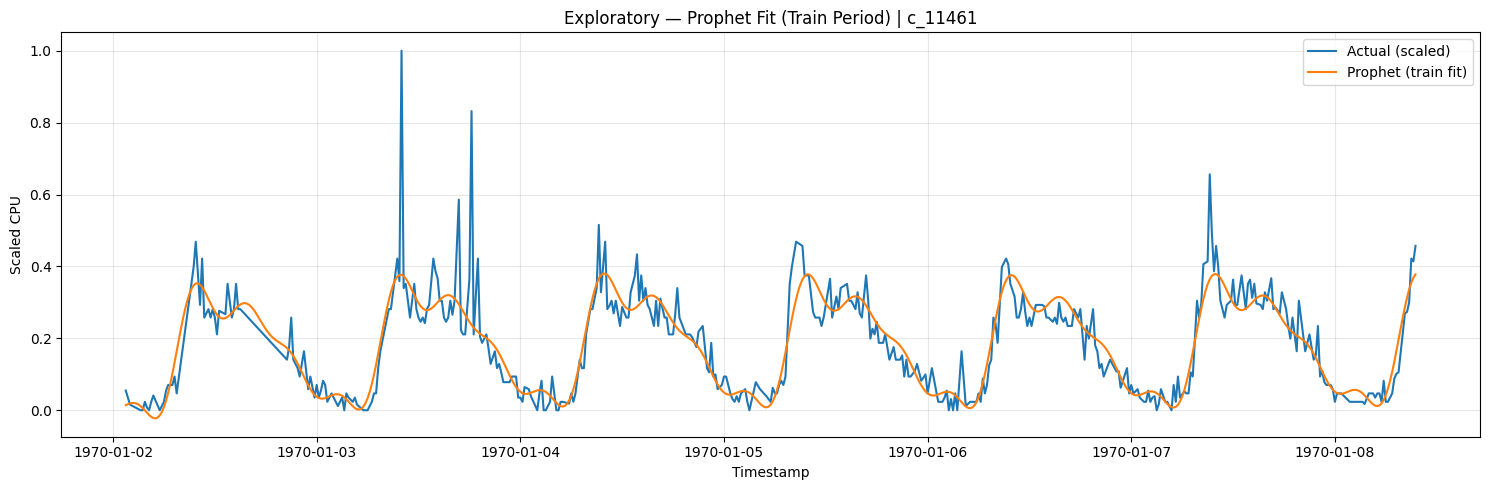

In [5]:
train_container = baseline_result.train_container.sort_values("time_stamp")
prophet_train_pred = baseline_result.train_forecast["yhat"].values

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_container["time_stamp"], train_container["cpu_scaled"], label="Actual (scaled)")
ax.plot(train_container["time_stamp"], prophet_train_pred, label="Prophet (train fit)")
ax.set_title(f"Exploratory — Prophet Fit (Train Period) | {TARGET_CID}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Scaled CPU")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Baseline — Primary Evaluation Plot (Day 1)

Same layout as `hybrid_model.ipynb` Primary Evaluation demo.


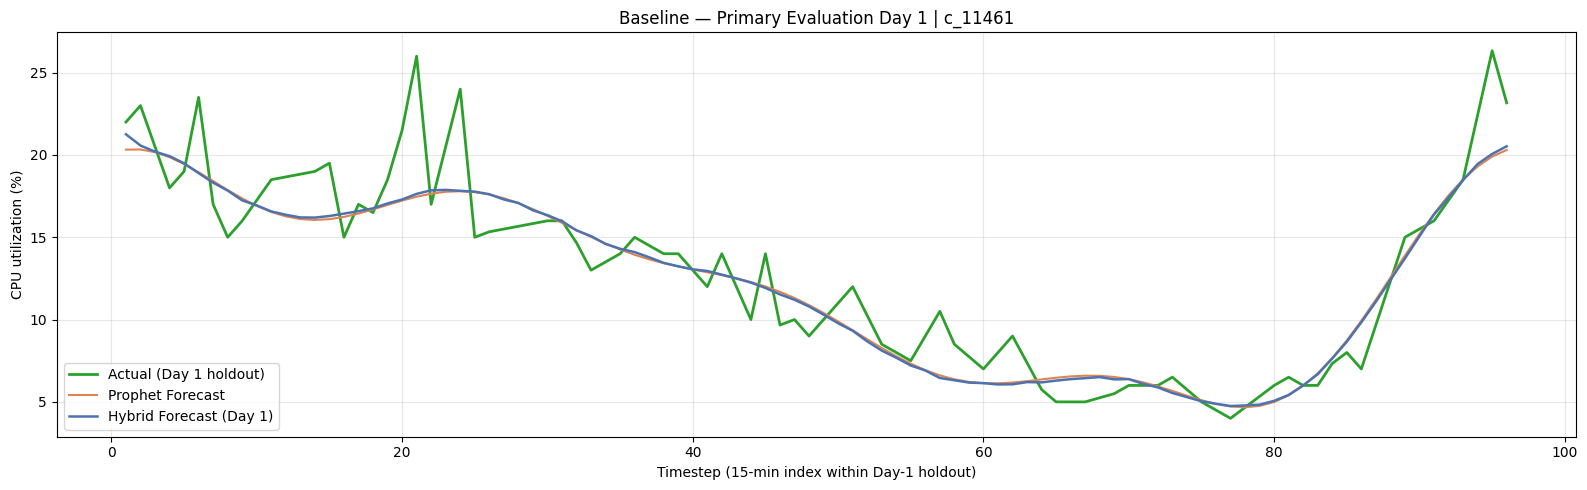

In [6]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(steps, baseline_result.actual_day1_real, color=COLOR_ACTUAL, linewidth=2, label="Actual (Day 1 holdout)")
ax.plot(steps, baseline_result.prophet_day1_real, color=COLOR_PROPHET, linewidth=1.5, label="Prophet Forecast")
ax.plot(steps, baseline_result.day1_final_real, color=COLOR_BASELINE, linewidth=1.8, label="Hybrid Forecast (Day 1)")
ax.set_title(f"Baseline — Primary Evaluation Day 1 | {TARGET_CID}")
ax.set_xlabel("Timestep (15-min index within Day-1 holdout)")
ax.set_ylabel("CPU utilization (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Peak-Aware — Primary Evaluation Plot (Day 1)

Identical axes and Prophet/Actual lines; GRU correction uses peak-aware weights.


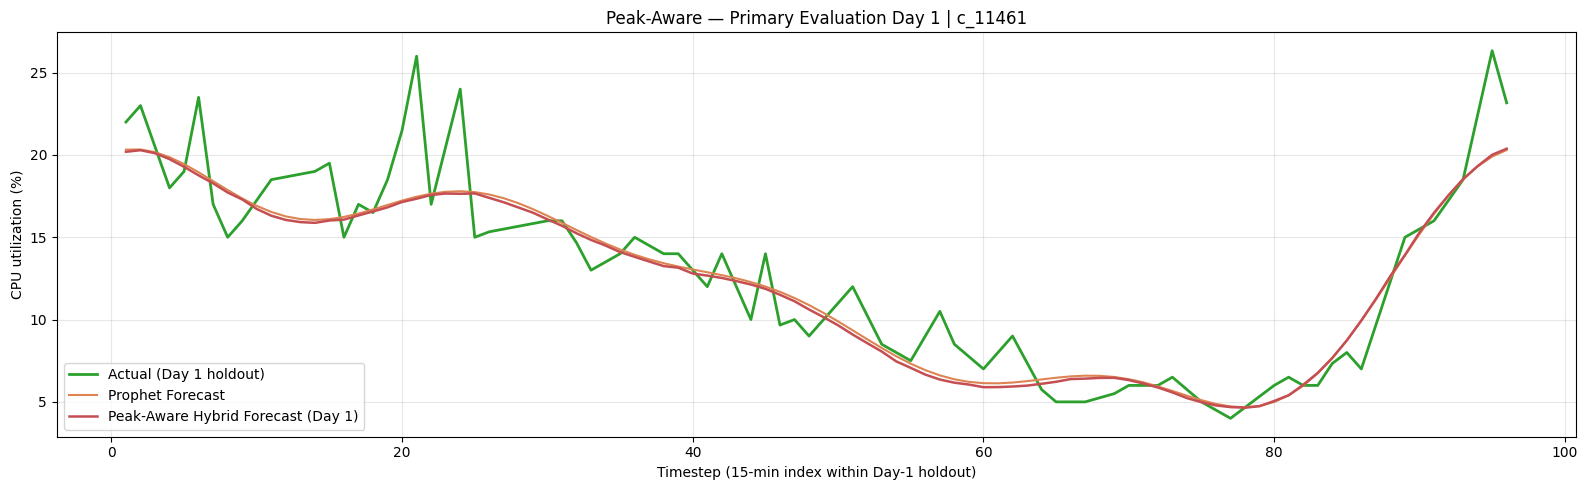

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(steps, peak_aware_result.actual_day1_real, color=COLOR_ACTUAL, linewidth=2, label="Actual (Day 1 holdout)")
ax.plot(steps, peak_aware_result.prophet_day1_real, color=COLOR_PROPHET, linewidth=1.5, label="Prophet Forecast")
ax.plot(steps, peak_aware_result.day1_final_real, color=COLOR_PEAK_AWARE, linewidth=1.8, label="Peak-Aware Hybrid Forecast (Day 1)")
ax.set_title(f"Peak-Aware — Primary Evaluation Day 1 | {TARGET_CID}")
ax.set_xlabel("Timestep (15-min index within Day-1 holdout)")
ax.set_ylabel("CPU utilization (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Combined Comparison — Actual vs Baseline vs Peak-Aware

Single overlay for direct visual comparison on identical axes.


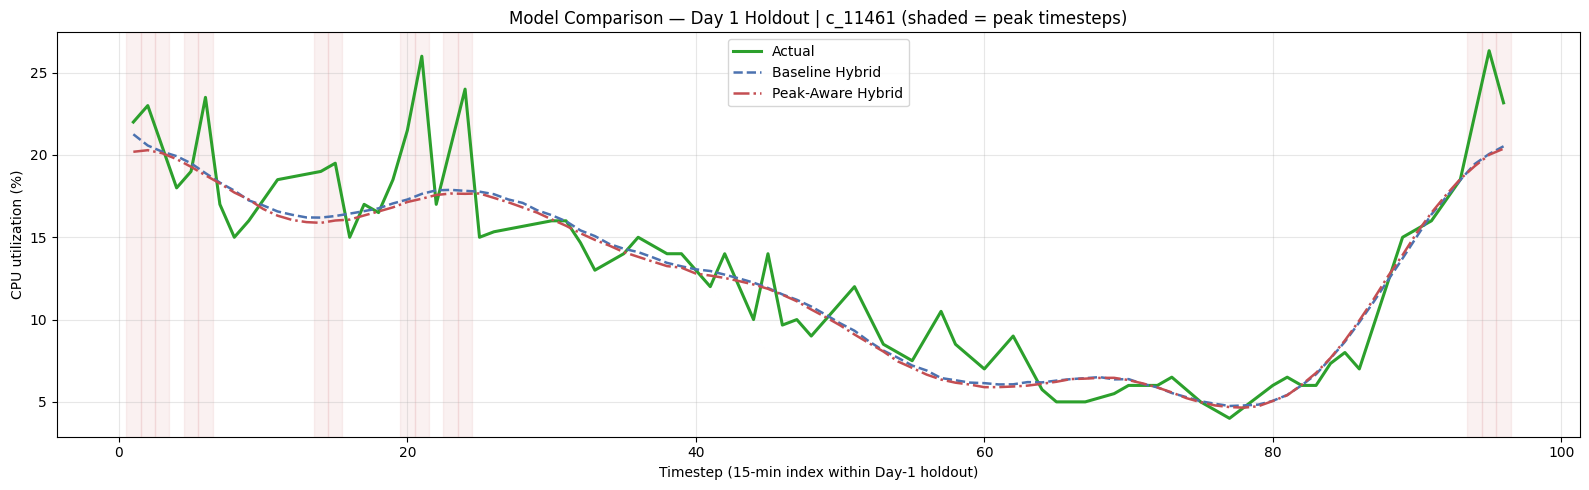

In [8]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(steps, baseline_result.actual_day1_real, color=COLOR_ACTUAL, linewidth=2.2, label="Actual")
ax.plot(steps, baseline_result.day1_final_real, color=COLOR_BASELINE, linewidth=1.8, linestyle="--", label="Baseline Hybrid")
ax.plot(steps, peak_aware_result.day1_final_real, color=COLOR_PEAK_AWARE, linewidth=1.8, linestyle="-.", label="Peak-Aware Hybrid")

# Shade peak timesteps on actual series
peak_idx = np.where(peak_mask)[0]
for idx in peak_idx:
    ax.axvspan(idx + 0.5, idx + 1.5, color="#C44E52", alpha=0.08)

ax.set_title(f"Model Comparison — Day 1 Holdout | {TARGET_CID} (shaded = peak timesteps)")
ax.set_xlabel("Timestep (15-min index within Day-1 holdout)")
ax.set_ylabel("CPU utilization (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Metrics — Overall, Peak Subset, and Deltas

Recomputes metrics from inference outputs and cross-checks saved Phase 5 `evaluation_df` rows.


In [9]:
def _metric_row(model_name: str, actual: np.ndarray, predicted: np.ndarray, threshold: float) -> dict:
    overall_mae, overall_rmse = compute_day1_metrics(actual, predicted)
    overall_mape = compute_day1_mape(actual, predicted)
    peak_metrics = compute_peak_subset_metrics_from_arrays(
        container_id=TARGET_CID,
        actual_day1_real=actual,
        day1_final_real=predicted,
        threshold=threshold,
    )
    return {
        "model": model_name,
        "day1_mae": overall_mae,
        "day1_rmse": overall_rmse,
        "day1_mape": overall_mape,
        "peak_mae": peak_metrics["peak_mae"],
        "peak_rmse": peak_metrics["peak_rmse"],
        "non_peak_mae": peak_metrics["non_peak_mae"],
        "non_peak_rmse": peak_metrics["non_peak_rmse"],
        "peak_steps": peak_metrics["peak_steps"],
        "non_peak_steps": peak_metrics["non_peak_steps"],
        "peak_fraction": peak_metrics["peak_fraction"],
    }

actual = baseline_result.actual_day1_real
metrics_df = pd.DataFrame([
    _metric_row("baseline", actual, baseline_result.day1_final_real, peak_threshold),
    _metric_row("peak_aware", actual, peak_aware_result.day1_final_real, peak_threshold),
])

baseline_row = metrics_df.loc[metrics_df["model"] == "baseline"].iloc[0]
peak_row = metrics_df.loc[metrics_df["model"] == "peak_aware"].iloc[0]

delta_df = pd.DataFrame([
    {
        "metric": "day1_mae",
        "baseline": baseline_row["day1_mae"],
        "peak_aware": peak_row["day1_mae"],
        "delta_peak_aware_minus_baseline": peak_row["day1_mae"] - baseline_row["day1_mae"],
    },
    {
        "metric": "day1_rmse",
        "baseline": baseline_row["day1_rmse"],
        "peak_aware": peak_row["day1_rmse"],
        "delta_peak_aware_minus_baseline": peak_row["day1_rmse"] - baseline_row["day1_rmse"],
    },
    {
        "metric": "day1_mape",
        "baseline": baseline_row["day1_mape"],
        "peak_aware": peak_row["day1_mape"],
        "delta_peak_aware_minus_baseline": peak_row["day1_mape"] - baseline_row["day1_mape"],
    },
    {
        "metric": "peak_mae",
        "baseline": baseline_row["peak_mae"],
        "peak_aware": peak_row["peak_mae"],
        "delta_peak_aware_minus_baseline": peak_row["peak_mae"] - baseline_row["peak_mae"],
    },
    {
        "metric": "peak_rmse",
        "baseline": baseline_row["peak_rmse"],
        "peak_aware": peak_row["peak_rmse"],
        "delta_peak_aware_minus_baseline": peak_row["peak_rmse"] - baseline_row["peak_rmse"],
    },
    {
        "metric": "non_peak_mae",
        "baseline": baseline_row["non_peak_mae"],
        "peak_aware": peak_row["non_peak_mae"],
        "delta_peak_aware_minus_baseline": peak_row["non_peak_mae"] - baseline_row["non_peak_mae"],
    },
    {
        "metric": "non_peak_rmse",
        "baseline": baseline_row["non_peak_rmse"],
        "peak_aware": peak_row["non_peak_rmse"],
        "delta_peak_aware_minus_baseline": peak_row["non_peak_rmse"] - baseline_row["non_peak_rmse"],
    },
])

# Pivot matrices for quick reading
overall_matrix = metrics_df.set_index("model")[
    ["day1_mae", "day1_rmse", "day1_mape"]
].round(4)

subset_matrix = metrics_df.set_index("model")[
    ["peak_mae", "peak_rmse", "non_peak_mae", "non_peak_rmse", "peak_steps", "peak_fraction"]
].round(4)

print("=" * 72)
print(f"METRICS — {TARGET_CID}")
print("=" * 72)
print(f"P90 threshold (train-fitted): {peak_threshold:.4f} %")
print()
print("Overall Day-1 matrix:")
display(overall_matrix)
print()
print("Peak / non-peak subset matrix:")
display(subset_matrix)
print()
print("Delta table (peak-aware − baseline):")
display(delta_df.round(4))

# Cross-check against saved Phase 5 evaluation CSVs
if BASELINE_EVAL_DF_PATH.exists() and TREATMENT_EVAL_DF_PATH.exists():
    saved_baseline = pd.read_csv(BASELINE_EVAL_DF_PATH)
    saved_treatment = pd.read_csv(TREATMENT_EVAL_DF_PATH)
    cross_check = pd.DataFrame([
        {
            "model": "baseline",
            "saved_day1_mae": float(saved_baseline.loc[saved_baseline["container_id"] == TARGET_CID, "day1_mae"].iloc[0]),
            "recomputed_day1_mae": float(baseline_row["day1_mae"]),
        },
        {
            "model": "peak_aware",
            "saved_day1_mae": float(saved_treatment.loc[saved_treatment["container_id"] == TARGET_CID, "day1_mae"].iloc[0]),
            "recomputed_day1_mae": float(peak_row["day1_mae"]),
        },
    ])
    cross_check["mae_abs_diff"] = (
        cross_check["saved_day1_mae"] - cross_check["recomputed_day1_mae"]
    ).abs()
    print()
    print("Cross-check vs saved evaluation_df (Day-1 MAE):")
    display(cross_check.round(6))


METRICS — c_11461
P90 threshold (train-fitted): 19.0000 %

Overall Day-1 matrix:


,day1_mae,day1_rmse,day1_mape
model,,,
baseline,1.4544,2.0343,11.7349
peak_aware,1.5034,2.1043,12.0568



Peak / non-peak subset matrix:


,peak_mae,peak_rmse,non_peak_mae,non_peak_rmse,peak_steps,peak_fraction
model,,,,,,
baseline,3.4164,4.0878,1.1194,1.4114,14,0.1458
peak_aware,3.6396,4.2675,1.1387,1.4405,14,0.1458



Delta table (peak-aware − baseline):


,metric,baseline,peak_aware,delta_peak_aware_minus_baseline
0,day1_mae,1.4544,1.5034,0.0490
1,day1_rmse,2.0343,2.1043,0.0700
2,day1_mape,11.7349,12.0568,0.3218
3,peak_mae,3.4164,3.6396,0.2232
4,peak_rmse,4.0878,4.2675,0.1796
5,non_peak_mae,1.1194,1.1387,0.0193
6,non_peak_rmse,1.4114,1.4405,0.0291



Cross-check vs saved evaluation_df (Day-1 MAE):


,model,saved_day1_mae,recomputed_day1_mae,mae_abs_diff
0,baseline,1.454416,1.454416,0.0
1,peak_aware,1.503433,1.503433,0.0


## Per-Timestep Error Matrix (Day 1)

Absolute error at each holdout timestep for baseline and peak-aware forecasts.


In [10]:
error_matrix = pd.DataFrame({
    "timestep": steps,
    "actual_cpu_pct": actual,
    "baseline_pred": baseline_result.day1_final_real,
    "peak_aware_pred": peak_aware_result.day1_final_real,
    "baseline_abs_error": np.abs(actual - baseline_result.day1_final_real),
    "peak_aware_abs_error": np.abs(actual - peak_aware_result.day1_final_real),
    "delta_abs_error": np.abs(actual - peak_aware_result.day1_final_real) - np.abs(actual - baseline_result.day1_final_real),
    "is_peak": peak_mask,
})

print("First 12 timesteps:")
display(error_matrix.head(12).round(4))

print()
print("Error summary by peak label:")
error_summary = error_matrix.groupby("is_peak")[
    ["baseline_abs_error", "peak_aware_abs_error", "delta_abs_error"]
].agg(["mean", "max"]).round(4)
display(error_summary)


ValueError: Per-column arrays must each be 1-dimensional